# #2 A/B Testing and Hypothesis Testing (t-test)

In [1]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing data

data = pd.read_csv('cleaned_data.csv', parse_dates=['date'])

**Based on the EDA done in 1_data_cleaning.ipynb, Facebook seems to be performing better than AdWords. But this cannot be directly concluded based on simply the mean and median of the data. To get a strong understanding, we will find the Pearson's correlation coefficient and perform Hypothesis Testing and answer the following question:**

### Which ad platform is more effective in terms of conversions, clicks, and overall cost-effectiveness?

# What is Pearson's Correlation Coefficient?

- Correlation describes the **strength and direction** of the relationship between two variables.

- Pearson's Correlation Coefficient measures the **linear relationship** between two variables.  
  This means it is only appropriate when the relationship between variables is approximately linear.

- The value of the correlation coefficient ranges between **-1 and +1**:
  - **+1** → Perfect positive correlation  
  - **-1** → Perfect negative correlation  
  - **0** → No correlation  

- The **sign (+ or -)** indicates the direction of the relationship:
  - **Positive correlation (+)**: As one variable increases, the other also increases.
  - **Negative correlation (-)**: As one variable increases, the other decreases.

- The **magnitude (absolute value)** indicates the strength:
  - Values closer to **1** (or -1) → Strong relationship  
  - Values closer to **0** → Weak relationship  
  
---

## Formula for Pearson's Correlation Coefficient:

The Pearson correlation coefficient between two variables (x and y) is:

$
\rho(x,y) = \frac{\operatorname{Cov}(x, y)}{\sigma_x \sigma_y}
$

Where covariance is defined as:

$
\operatorname{Cov}(x, y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu_x)(y_i - \mu_y)
$

Where:

- $\rho$ is the Pearson's Correlation Coefficient
- $\operatorname{Cov}$ denotes the Covariance
- $x_i, y_i$ are individual data points  
- $\mu_x, \mu_y$ are the means of x and y  
- $\sigma_x, \sigma_y$ are the standard deviations of x and y
- $N$ is the number of data points

## Identifying the relationship between clicks and conversion for both platforms.

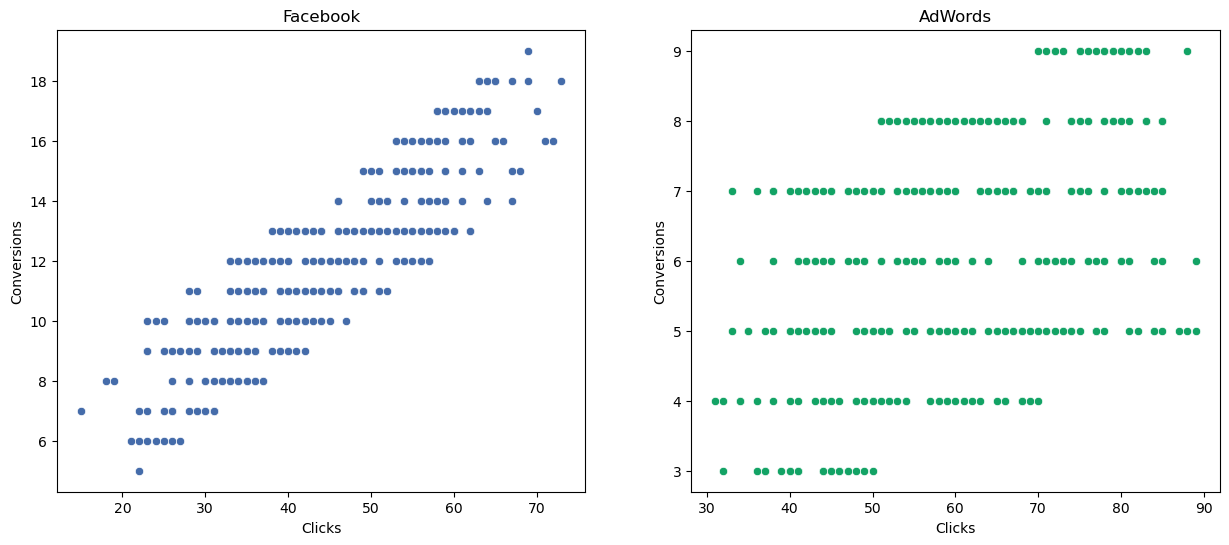

In [3]:
# plotting number of clicks vs conversion for both platforms to identify the trend

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(x = data['facebook_ad_clicks'],y = data['facebook_ad_conversions'], color='#456caa')
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.subplot(1,2,2)
plt.title('AdWords')
sns.scatterplot(x = data['adwords_ad_clicks'],y = data['adwords_ad_conversions'], color='#13a365')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.show()

**It can be seen that the relation between Number of Clicks and Number of Conversions for both platforms is linear. The relationship in case of AdWords is more scattered than what is seen for Facebook, nevertheless both relations are linear and it makes sense to calculate the Pearson's Correlation Coefficient next.** 

In [4]:
# Calculating the Pearson's Correlation Coefficient Matrix

adwords_corr = data[['adwords_ad_conversions', 'adwords_ad_clicks']].corr()
facebook_corr = data[['facebook_ad_conversions', 'facebook_ad_clicks']].corr()

print('The Correlation Matrix for AdWords Campaign:\n', adwords_corr)
print('\n')
print('The Correlation Matrix for Facebook Campaign:\n', facebook_corr)

The Correlation Matrix for AdWords Campaign:
                         adwords_ad_conversions  adwords_ad_clicks
adwords_ad_conversions                1.000000           0.447993
adwords_ad_clicks                     0.447993           1.000000


The Correlation Matrix for Facebook Campaign:
                          facebook_ad_conversions  facebook_ad_clicks
facebook_ad_conversions                 1.000000            0.873775
facebook_ad_clicks                      0.873775            1.000000


In [5]:
# Getting the correlation coefficient from the above matrix

print('Correlation Coefficient:')

print('AdWords : ',round(adwords_corr.values[0,1],2))
print('Facebook :',round(facebook_corr.values[0,1],2))

Correlation Coefficient:
AdWords :  0.45
Facebook : 0.87


## Observations:

- The Facebook Campaign has a correlation of 0.87 between clicks and conversions which is a strong positive relationship. It shows that as the number of clicks on Facebook ads increase, the conversions also increase. This suggests that Facebook advertisements are highly effective and increasing the investment in Facebook ads or optimizing their performance could potentially lead to even higher sales.
- A correlation of 0.45 shows a moderate positive relationship between clicks and conversions in the AdWords Campaign. While the relationship is positive, it is not as strong as that seen in the Facebook Campaign. This moderate relationship suggests that while AdWords ads contribute to conversions, there are other factors as well which need to be identified and optimized to make the AdWords Campaign more effective.

# Hypothesis Testing and T-Test

### What is Hypothesis Testing?

Hypothesis testing is a statistical method used to make decisions or inferences about a population based on sample data.

- We start with two hypotheses:
  - **Null Hypothesis (H₀)**: Assumes no effect or no difference.
  - **Alternative Hypothesis (H₁)**: Assumes there is an effect or a difference.

- The goal is to determine whether there is enough evidence to **reject the null hypothesis**.

---

### What is a T-Test?

A **T-test** is used to compare the means of two groups and determine whether they are **statistically different** from each other.

### When is T-Test used?

- When **sample size is small (n ≤ 30)**  
- OR when the **population standard deviation is unknown**

Even with larger datasets, a T-test is commonly used when the population standard deviation is not known.

---

**Type of T-Test Used**

We use:

`ttest_ind()`

- Performs a **two-sample independent t-test**
- Used to compare means of **two independent groups**

**In this case:**

We are testing whether:

> The average conversions from **Facebook** and **AdWords** are statistically different.

---

**Function Details:**

From `scipy.stats`:

`ttest_ind(a, b, equal_var=False)`

Arguments:  
`a` → Sample A (e.g., Facebook conversions)  
`b` → Sample B (e.g., AdWords conversions)  
`equal_var=False` → To let python know to not assume equal variance between the two samples 

**Output of T-Test:**

The function returns:
- t-statistic
- p-value

### Understanding the T-Statistic

The t-statistic measures the difference between group means relative to the variability of the data.


$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

Breakdown of Symbols:  
$\bar{x}_1, \bar{x}_2$: Means of the two samples.  
$s_1^2, s_2^2$: Variances of the two samples.  
$n_1, n_2$: Sizes of the two samples.  
${\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$: The pooled variability (standard error) of the difference between means.  

**Interpretation:**
| t-value |	Meaning |
| :--- | :--- |
| Near 0 |	Means are similar |
| Large positive |	Mean of group A > Mean of group B |
| Large negative |	Mean of group B > Mean of group A |

**Understanding the P-Value:**  
The p-value tells us how likely it is to observe the result assuming the null hypothesis is true.
It is computed using the t-distribution.  

**Decision Rule:**  
If p-value < 0.05 → Reject H₀ (statistically significant difference)  
If p-value ≥ 0.05 → Fail to reject H₀ (no significant difference)

---
Based on the analysis done so far, we make the following hypothesis:

**Null Hypothesis $(H_0)$:** There is no difference in the number of conversions between Facebook and AdWords.

**Alternate Hypothesis $(H_1)$:** There is a significant difference in the number of conversions between Facebook and AdWords and The number of conversions from Facebook is greater than the number of conversions from AdWords.

$H_0: \ \mu_{\text{Facebook}} \leq \mu_{\text{AdWords}}$

$H_1: \ \mu_{\text{Facebook}} > \mu_{\text{AdWords}}$

## Performing Welch's t-test:

A two-sample t-test is used to compare the mean conversions between Facebook and AdWords campaigns. Although the sample size (365 observations) is large, the true population standard deviation is unknown. Therefore, the t-test is appropriate as it estimates variance using the sample standard deviation. For large samples, the t-distribution closely approximates the normal distribution, making the t-test a reliable choice.

In [6]:
# T-test

print('Mean Conversion \n--------------')
print('Facebook :', round(data['facebook_ad_conversions'].mean(),2))
print('AdWords :', round(data['adwords_ad_conversions'].mean(),2))

t_stats, p_value = st.ttest_ind(a = data['facebook_ad_conversions'], b = data['adwords_ad_conversions'], equal_var = False)
print('\nT statistic', t_stats, '\np-value',p_value)

# comparing the p value with the significance of 5% or 0.05
alpha = 0.05
if p_value < alpha:
    print("\np-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Fail to reject the null hypothesis")

Mean Conversion 
--------------
Facebook : 11.74
AdWords : 5.98

T statistic 32.88402060758184 
p-value 9.348918164530465e-134

p-value is less than significance value, Reject the null hypothesis


## Observations

- The **mean conversions** for Facebook (**11.74**) are significantly higher than AdWords (**5.98**).

- The computed **t-statistic (32.88)** is very large and positive, indicating a strong difference between the two group means.

- The **p-value $(9.35 * 10^{-134})$** is extremely small and much lower than the significance level (α = 0.05).

- Since **p-value < α**, we **reject the null hypothesis (H₀)**.

- There is **strong statistical evidence** to conclude that: $\mu_{\text{Facebook}} > \mu_{\text{AdWords}}$

- This implies that **Facebook ads generate significantly higher conversions than AdWords ads** in this dataset.

---

## Conclusion

- The difference in conversions is **not due to random chance**.
- Facebook appears to be the **better-performing platform** in terms of conversions.